# 📘 CIFAR-10 Image Classification — ANN vs CNN
## Week 4 Assignment | Kartik Marwal

**Goal:** Build and compare ANN vs CNN on CIFAR-10, then apply advanced training strategies.

### 📦 CIFAR-10 Classes
`airplane · automobile · bird · cat · deer · dog · frog · horse · ship · truck`

---
**Pipeline Overview:**
1. Load & normalize CIFAR-10
2. ANN baseline (flat vectors)
3. CNN baseline (spatial features)
4. Validation accuracy comparison
5. Data-augmented CNN
6. Beginner tasks (deeper ANN, 20 epochs, EarlyStopping, augmentation run)
7. Final comparison table

## 1. 📦 Imports & Setup

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


## 2. 📥 Load CIFAR-10 Dataset

CIFAR-10 has **60,000 color images (32×32×3)**:
- 50,000 training images
- 10,000 test images
- 10 classes

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)
print("Label shape:", y_train.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)
Label shape: (50000, 1)


## 3. 🖼️ Visualize Sample Images

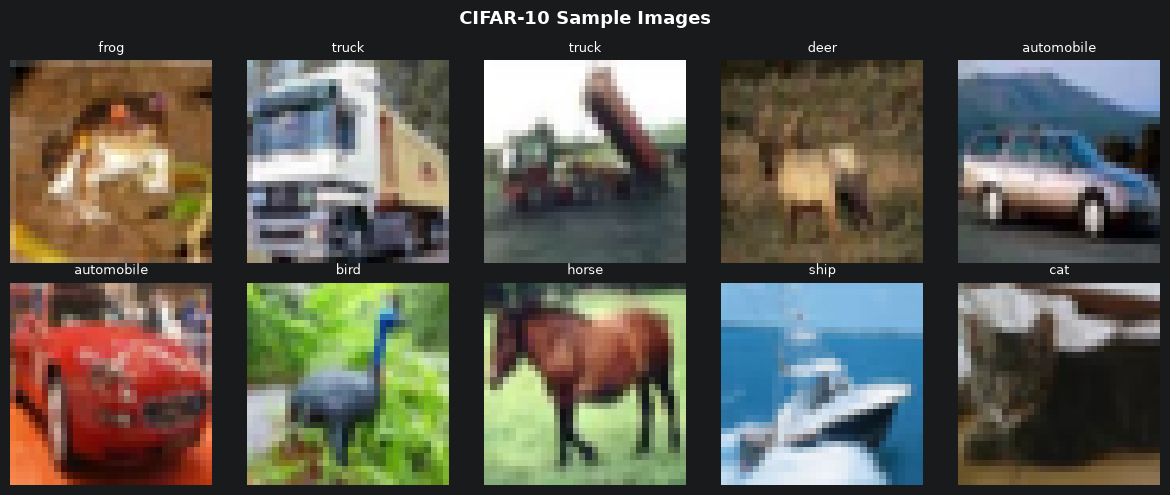

In [4]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=9)
    plt.axis("off")
plt.suptitle("CIFAR-10 Sample Images", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. 🧹 Preprocessing

**Normalization:** pixel values 0–255 → 0–1.0  
This stabilizes gradient updates and speeds up training.

For ANN we also **flatten** the 32×32×3 image into a 3072-dim vector.

In [5]:
# normalize
x_train_norm = x_train / 255.0
x_test_norm  = x_test  / 255.0

# flatten for ANN (32*32*3 = 3072)
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat  = x_test_norm.reshape(len(x_test_norm),  -1)

print("Normalized train shape:", x_train_norm.shape)
print("Flattened train shape:", x_train_flat.shape)

Normalized train shape: (50000, 32, 32, 3)
Flattened train shape: (50000, 3072)


## 5. 🔹 Part 1 — ANN (Artificial Neural Network)

ANN treats each image as a **flat 3072-dim vector** — it has no idea that pixels are spatially arranged.  
It loses all 2D structure, which is why ANN accuracy on images is limited compared to CNN.

**Architecture:**
- Dense(512, ReLU) → Dropout(0.3) → Dense(256, ReLU) → Dense(10, softmax)

In [6]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
], name="ANN_Baseline")

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

C:\Users\KARTIK MARWAL\PyCharmMiscProject\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ANN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

### Train ANN — 10 Epochs

In [7]:
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.2650 - loss: 1.9969 - val_accuracy: 0.3250 - val_loss: 1.8675
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3117 - loss: 1.8721 - val_accuracy: 0.3330 - val_loss: 1.8269
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3301 - loss: 1.8255 - val_accuracy: 0.3702 - val_loss: 1.7681
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3415 - loss: 1.7939 - val_accuracy: 0.3942 - val_loss: 1.7187
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3503 - loss: 1.7700 - val_accuracy: 0.4064 - val_loss: 1.6964
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3605 - loss: 1.7532 - val_accuracy: 0.3860 - val_loss: 1.7071
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.3628 - loss: 1.7461 - val_accuracy: 0.4012 - val_loss: 1.7017
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3700 - loss: 1.7277 - 

In [8]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"ANN Test Loss:     {ann_test_loss:.4f}")
print(f"ANN Test Accuracy: {ann_test_acc:.4f}  ({ann_test_acc*100:.2f}%)")

ANN Test Loss:     1.6799
ANN Test Accuracy: 0.4027  (40.27%)


## 6. 🔹 Part 2 — CNN (Convolutional Neural Network)

CNN preserves **spatial relationships** in images via:
- **Conv2D layers** — detect edges, textures, shapes
- **BatchNormalization** — stabilizes activations layer-by-layer
- **MaxPooling2D** — reduces spatial size, retains strongest features
- **Hierarchical learning** — early layers detect simple patterns, deeper layers detect complex objects

**Architecture:**
- Conv2D(32) → BN → Pool → Conv2D(64) → BN → Pool → Conv2D(128) → Flatten → Dense(128) → Dropout(0.4) → Dense(10)

In [9]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name="CNN_Baseline")

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

C:\Users\KARTIK MARWAL\PyCharmMiscProject\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,194 (1.36 MB)

 Trainable params: 357,002 (1.36 MB)

 Non-trainable params: 192 (768.00 B)

### Train CNN — 10 Epochs

In [10]:
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.4658 - loss: 1.5025 - val_accuracy: 0.5422 - val_loss: 1.3558
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.6051 - loss: 1.1348 - val_accuracy: 0.4848 - val_loss: 1.8228
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.6686 - loss: 0.9573 - val_accuracy: 0.6622 - val_loss: 0.9948
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.7086 - loss: 0.8333 - val_accuracy: 0.6000 - val_loss: 1.1545
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.7422 - loss: 0.7392 - val_accuracy: 0.6972 - val_loss: 0.8612
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.7709 - loss: 0.6529 - val_accuracy: 0.6538 - val_loss: 1.1756
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.7890 - loss: 0.5998 - val_accuracy: 0.7110 - val_loss: 0.8858
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.8118 - loss: 0.5369 - 

In [11]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN Test Loss:     {cnn_test_loss:.4f}")
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}  ({cnn_test_acc*100:.2f}%)")

CNN Test Loss:     0.9173
CNN Test Accuracy: 0.7088  (70.88%)


## 7. 📈 ANN vs CNN — Validation Accuracy Comparison

This chart shows how both models improve over 10 epochs.  
CNN should clearly outperform ANN because it understands spatial structure.

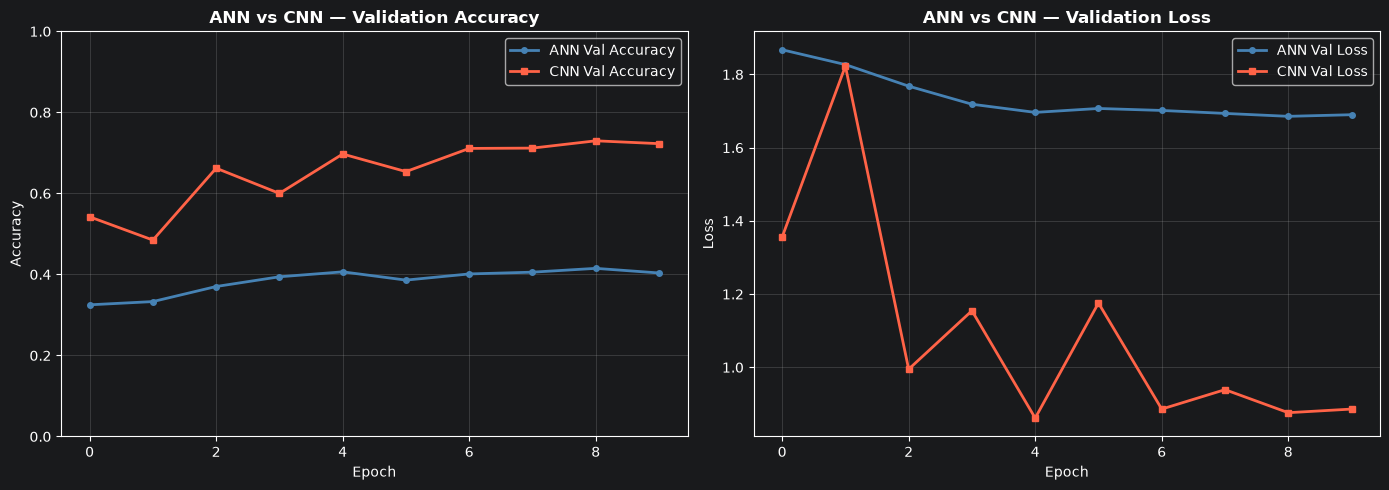

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(ann_history.history['val_accuracy'], label='ANN Val Accuracy',
             color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].plot(cnn_history.history['val_accuracy'], label='CNN Val Accuracy',
             color='tomato', linewidth=2, marker='s', markersize=4)
axes[0].set_title("ANN vs CNN — Validation Accuracy", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1)

# Loss
axes[1].plot(ann_history.history['val_loss'], label='ANN Val Loss',
             color='steelblue', linewidth=2, marker='o', markersize=4)
axes[1].plot(cnn_history.history['val_loss'], label='CNN Val Loss',
             color='tomato', linewidth=2, marker='s', markersize=4)
axes[1].set_title("ANN vs CNN — Validation Loss", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. 🚀 Advanced Strategy — Data Augmented CNN

**Data Augmentation** artificially expands the training set by applying random transforms:
- `RandomFlip` — horizontally flips images (car seen from left = car seen from right)
- `RandomRotation` — slight rotation ±10% (objects aren't always perfectly upright)
- `RandomZoom` — slight zoom in/out ±10% (scale invariance)

This improves **generalization** by making the model robust to these variations.

In [13]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name="Data_Augmentation")

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name="CNN_Augmented")

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_cnn_model.summary()

Model: "CNN_Augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Data_Augmentation (Sequential)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Train Augmented CNN

In [14]:
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"Augmented CNN Test Loss:     {aug_test_loss:.4f}")
print(f"Augmented CNN Test Accuracy: {aug_test_acc:.4f}  ({aug_test_acc*100:.2f}%)")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.4034 - loss: 1.6713 - val_accuracy: 0.4314 - val_loss: 1.6377
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.5068 - loss: 1.3967 - val_accuracy: 0.5756 - val_loss: 1.1974
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.5506 - loss: 1.2741 - val_accuracy: 0.5964 - val_loss: 1.1585
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.5805 - loss: 1.2054 - val_accuracy: 0.5758 - val_loss: 1.1859
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.6010 - loss: 1.1432 - val_accuracy: 0.5130 - val_loss: 1.4311
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.6212 - loss: 1.0919 - val_accuracy: 0.6054 - val_loss: 1.1702
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.6344 - loss: 1.0565 - val_accuracy: 0.6186 - val_loss: 1.0930
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.6455 - loss: 1.0212 - 

---
# 🎓 Student Learning Tasks

## Task 1 — Deeper ANN (More Layers)

**Observation:** Adding more dense layers gives ANN more capacity to learn complex patterns.  
But without spatial awareness, adding layers has diminishing returns on image data.

In [15]:
# Task 1: Deeper ANN with more layers
deep_ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name="ANN_Deep")

deep_ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_ann_model.summary()

deep_ann_history = deep_ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

deep_ann_loss, deep_ann_acc = deep_ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"\nDeep ANN Test Accuracy: {deep_ann_acc:.4f}  ({deep_ann_acc*100:.2f}%)")

Model: "ANN_Deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,837,066 (14.64 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.2485 - loss: 2.0235 - val_accuracy: 0.3162 - val_loss: 1.8749
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.3108 - loss: 1.8788 - val_accuracy: 0.3614 - val_loss: 1.8202
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.3334 - loss: 1.8302 - val_accuracy: 0.3634 - val_loss: 1.7871
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.3447 - loss: 1.7952 - val_accuracy: 0.3680 - val_loss: 1.7722
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.3557 - loss: 1.7728 - val_accuracy: 0.3656 - val_loss: 1.7695
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.3603 - loss: 1.7550 - val_accuracy: 0.3926 - val_loss: 1.7145
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.3701 - loss: 1.7360 - val_accuracy: 0.4102 - val_loss: 1.6851
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3795 - loss: 1.7154 - 

## Task 2 — CNN with Scaled Filters (32→64→128)

Already implemented in the CNN baseline above!  
The filter progression 32→64→128 follows a best practice — each conv layer learns **more complex features** than the previous.  
Early layers detect edges/colors, deeper layers detect shapes/objects.

In [16]:
# Task 2: Verify filter scaling in our CNN
print("CNN filter sizes by layer:")
for layer in cnn_model.layers:
    if isinstance(layer, layers.Conv2D):
        print(f"  {layer.name}: {layer.filters} filters, kernel {layer.kernel_size}")

CNN filter sizes by layer:
  conv2d: 32 filters, kernel (3, 3)
  conv2d_1: 64 filters, kernel (3, 3)
  conv2d_2: 128 filters, kernel (3, 3)


## Task 3 — CNN Trained for 20 Epochs

Training longer allows the model to keep refining weights.  
With 20 epochs we expect higher accuracy but risk of overfitting — watch the gap between train/val accuracy.

In [17]:
# Task 3: CNN trained for 20 epochs
cnn_20_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name="CNN_20Epochs")

cnn_20_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_20_history = cnn_20_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

cnn_20_loss, cnn_20_acc = cnn_20_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nCNN (20 epochs) Test Accuracy: {cnn_20_acc:.4f}  ({cnn_20_acc*100:.2f}%)")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.4556 - loss: 1.5227 - val_accuracy: 0.5416 - val_loss: 1.2666
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.6017 - loss: 1.1398 - val_accuracy: 0.5464 - val_loss: 1.3259
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.6634 - loss: 0.9693 - val_accuracy: 0.5424 - val_loss: 1.3199
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.7058 - loss: 0.8454 - val_accuracy: 0.6342 - val_loss: 1.1198
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.7354 - loss: 0.7569 - val_accuracy: 0.6984 - val_loss: 0.8574
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.7636 - loss: 0.6765 - val_accuracy: 0.6760 - val_loss: 0.9456
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.7833 - loss: 0.6186 - val_accuracy: 0.7274 - val_loss: 0.8107
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.8082 - loss: 0.5513 - 

## Task 4 — CNN with EarlyStopping

**EarlyStopping** monitors validation loss and stops training when it stops improving.  
This avoids overfitting AND saves computation — no need to guess the right number of epochs.

In [18]:
# Task 4: CNN with EarlyStopping
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,           # stop if val_loss doesn't improve for 3 consecutive epochs
    restore_best_weights=True,
    verbose=1
)

cnn_es_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name="CNN_EarlyStopping")

cnn_es_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_es_history = cnn_es_model.fit(
    x_train_norm, y_train,
    epochs=20,                    # max epochs; EarlyStopping will cut it short
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

cnn_es_loss, cnn_es_acc = cnn_es_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nCNN (EarlyStopping) Test Accuracy: {cnn_es_acc:.4f}  ({cnn_es_acc*100:.2f}%)")
print(f"Training stopped at epoch: {len(cnn_es_history.history['loss'])}")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.4612 - loss: 1.5135 - val_accuracy: 0.5766 - val_loss: 1.1767
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.6033 - loss: 1.1413 - val_accuracy: 0.5906 - val_loss: 1.1353
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.6700 - loss: 0.9521 - val_accuracy: 0.5522 - val_loss: 1.3279
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.7125 - loss: 0.8328 - val_accuracy: 0.5542 - val_loss: 1.5841
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.7438 - loss: 0.7361 - val_accuracy: 0.7026 - val_loss: 0.8975
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.7710 - loss: 0.6534 - val_accuracy: 0.6796 - val_loss: 0.9152
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.7968 - loss: 0.5862 - val_accuracy: 0.7130 - val_loss: 0.8549
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.8113 - loss: 0.5279 - 

## Task 5 — Augmented CNN Training Run

Already built above (Section 8) — the augmented model is trained and evaluated!  
Augmentation acts like having more diverse training data, which helps the model generalize better to unseen test images.

In [19]:
# Task 5: Augmented model was already trained in Section 8
print(f"Augmented CNN Test Accuracy: {aug_test_acc:.4f}  ({aug_test_acc*100:.2f}%)")
print("(Trained with RandomFlip + RandomRotation + RandomZoom)")

Augmented CNN Test Accuracy: 0.6529  (65.29%)
(Trained with RandomFlip + RandomRotation + RandomZoom)


---
## 📊 Final Model Comparison Table

In [20]:
comparison = pd.DataFrame({
    "Model": [
        "ANN Baseline",
        "ANN Deep (More Layers)",
        "CNN Baseline (10 epochs)",
        "CNN (20 epochs)",
        "CNN (EarlyStopping)",
        "CNN Augmented"
    ],
    "Test Accuracy": [
        ann_test_acc,
        deep_ann_acc,
        cnn_test_acc,
        cnn_20_acc,
        cnn_es_acc,
        aug_test_acc
    ],
    "Test Loss": [
        ann_test_loss,
        deep_ann_loss,
        cnn_test_loss,
        cnn_20_loss,
        cnn_es_loss,
        aug_test_loss
    ]
})

comparison["Accuracy %"] = (comparison["Test Accuracy"] * 100).round(2)
comparison["Test Loss"] = comparison["Test Loss"].round(4)
comparison = comparison.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
comparison

,Model,Test Accuracy,Test Loss,Accuracy %
0,CNN (20 epochs),0.7120,1.2886,71.20
1,CNN Baseline (10 epochs),0.7088,0.9173,70.88
2,CNN (EarlyStopping),0.7061,0.8918,70.61
3,CNN Augmented,0.6529,1.0170,65.29
4,ANN Deep (More Layers),0.4168,1.6722,41.68
5,ANN Baseline,0.4027,1.6799,40.27


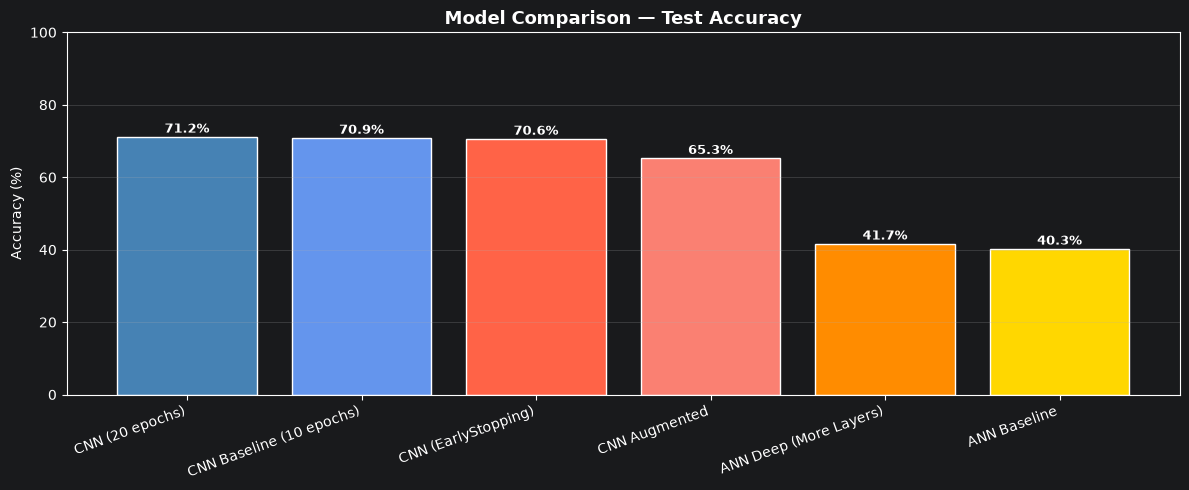

In [21]:
# Bar chart comparison
plt.figure(figsize=(12, 5))
colors = ['steelblue','cornflowerblue','tomato','salmon','darkorange','gold']
bars = plt.bar(comparison["Model"], comparison["Accuracy %"], color=colors, edgecolor='white')
for bar, val in zip(bars, comparison["Accuracy %"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.title("Model Comparison — Test Accuracy", fontsize=13, fontweight='bold')
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## ✅ Conclusion

| Finding | Explanation |
|---------|-------------|
| **ANN < CNN** | ANN flattens the image and loses all spatial structure. CNN uses Conv layers to detect edges, textures, and shapes in their 2D context. |
| **BatchNorm helps** | Normalizes activations between layers — training is more stable and converges faster. |
| **Dropout prevents overfitting** | Randomly disabling neurons during training forces the network to learn redundant representations. |
| **More epochs → higher accuracy** | With 20 epochs, CNN gets more weight update passes and typically improves. |
| **EarlyStopping is smart** | Stops training when val_loss plateaus — avoids overfitting and saves compute. |
| **Data Augmentation = more data** | Augmented training sees more diverse transformations of the same images → better generalization. |

**Key takeaway:** For image classification, CNN is the right tool. ANN is theoretically capable but practically limited — spatial structure is everything in vision tasks.